# 1. Introdução

### Previsão de Rotatividade e Segmentação de Clientes: Rede Model Fitness

A retenção de clientes é um dos maiores desafios para modelos de negócio baseados em assinatura. Na indústria fitness, academias frequentemente lidam com altas taxas de evasão (churn), perdendo receitas recorrentes que poderiam ser preservadas por meio de intervenções preventivas.

Neste projeto, atuamos na estruturação de dados para a rede de academias Model Fitness. O objetivo central é analisar o histórico de uso, as características demográficas e o engajamento dos clientes para desenvolver uma estratégia de retenção proativa e orientada a dados (data-driven).

Para resolver este problema de negócios, a análise técnica será dividida em duas frentes de Machine Learning:

- Aprendizado Supervisionado (Previsão): Construção e avaliação de modelos de classificação (como Regressão Logística e Random Forest) para prever a probabilidade de cancelamento de um usuário no curto prazo.

- Aprendizado Não Supervisionado (Clusterização): Aplicação de agrupamento hierárquico e do algoritmo K-Means para segmentar a base de clientes em nichos comportamentais, isolando as variáveis que definem perfis leais e perfis de alto risco.

Ao final da esteira de dados, os padrões matemáticos identificados pelos algoritmos serão traduzidos em recomendações estratégicas e acionáveis, fornecendo à diretoria e à equipe de marketing da Model Fitness os subsídios necessários para otimizar o relacionamento com os alunos e reduzir os cancelamentos.

# 2. Carregamento dos dados

In [1]:
# Importando bibliotecas necessárias

# Manipulação e visualização de dados
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Pré-processamento e validação
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Métricas
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Agrupamento (Clustering)
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
# Carregando os dados
gym = pd.read_csv('/datasets/gym_churn_us.csv')

gym.info()
print('=='*50)
print(gym.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

# 3. Análise Exploratória de Dados

Antes de introduzirmos algoritmos de Machine Learning, precisamos compreender a estrutura e o comportamento bruto do nosso conjunto de dados. A Análise Exploratória de Dados (EDA) atua como o diagnóstico inicial do projeto.

Nesta etapa, o objetivo é mapear as distribuições estatísticas das características dos clientes da Model Fitness, avaliar a integridade da base e investigar as primeiras correlações entre as variáveis de comportamento (como frequência, idade e tempo de contrato) e a nossa variável alvo (Churn). As métricas e visualizações levantadas aqui servirão como a base lógica para justificar as decisões de modelagem estatística nas fases seguintes.

In [3]:
# Usamos o método describe para fazer um "sanity check" inicial
print(gym.describe())

            gender  Near_Location      Partner  Promo_friends        Phone  \
count  4000.000000    4000.000000  4000.000000    4000.000000  4000.000000   
mean      0.510250       0.845250     0.486750       0.308500     0.903500   
std       0.499957       0.361711     0.499887       0.461932     0.295313   
min       0.000000       0.000000     0.000000       0.000000     0.000000   
25%       0.000000       1.000000     0.000000       0.000000     1.000000   
50%       1.000000       1.000000     0.000000       0.000000     1.000000   
75%       1.000000       1.000000     1.000000       1.000000     1.000000   
max       1.000000       1.000000     1.000000       1.000000     1.000000   

       Contract_period  Group_visits          Age  \
count      4000.000000   4000.000000  4000.000000   
mean          4.681250      0.412250    29.184250   
std           4.549706      0.492301     3.258367   
min           1.000000      0.000000    18.000000   
25%           1.000000      0.00

O método faz uma segunda confirmação de que não existem valores ausentes em nossos dados. Outro ponto interessante, para variáveis binárias (representando valores booleanos), a média nos fornece a proporção do evento. Por exemplo, para a variável Churn, a média é de 0.265, ou seja, a taxa de cancelamento é de aproximadamente 26,5%. Da mesma forma, podemos identificar também que 84.5% dos usuários moram ou trabalham próximos à academia.
Por fim, vemos a importância e a necessidade de padronizar nossos dados, pois a coluna Avg_additional_charges_total possui um valor máximo de 552.6, muito superior aos valores das colunas binárias, ou com a coluna de idade. Alguns algoritmos calculam a distância matemática entre os pontos, se utilizarmos os dados não tratados/padronizados nos modelos, eles irão considerar os gastos adicionais como extremamente importantes pois os valores absolutos são maiores.

In [4]:
# Agrupamos nosso DataFrame pela coluna Churn para comparar as médias dos grupos 
# que ficaram e dos que saíram
mean_churn = gym.groupby('Churn').mean()

print(mean_churn)

         gender  Near_Location   Partner  Promo_friends     Phone  \
Churn                                                               
0      0.510037       0.873086  0.534195       0.353522  0.903709   
1      0.510839       0.768143  0.355325       0.183789  0.902922   

       Contract_period  Group_visits        Age  Avg_additional_charges_total  \
Churn                                                                           
0             5.747193      0.464103  29.976523                    158.445715   
1             1.728558      0.268615  26.989632                    115.082899   

       Month_to_end_contract  Lifetime  Avg_class_frequency_total  \
Churn                                                               
0                   5.283089  4.711807                   2.024876   
1                   1.662582  0.990575                   1.474995   

       Avg_class_frequency_current_month  
Churn                                     
0                               2.0

Podemos identificar logo de cara que as variáveis "gender" e "Phone" são neutras, pois as médias para os dois grupos são praticamente idênticas. Para as demais variáveis, observamos variações significativas. De fato, os usuários que deixam de ir à academia dão indícios silenciosos antes do cancelamento efetivo. Naturalmente, a frequência média semanal de treino para o grupo que cancela o plano é menor do que a dos usuários retidos. E quando estão mais próximos de desistir, eles diminuem ainda mais essa frequência no mês anterior.

A duração do contrato também impacta na decisão de sair: contratos mais longos estimulam a permanência, enquanto contratos mensais facilitam a desistência rápida. Fatores sociais também demonstram ser grandes incentivadores na retenção. Nas variáveis "Group_visits" e "Promo_friends", as médias dos usuários que não cancelam são consideravelmente maiores, indicando que o senso de comunidade é um ótimo estimulante para manter os usuários ativos. Além disso, clientes que cancelam costumam ter menos gastos adicionais, o que mostra que, se um usuário é mais engajado com o ecossistema da academia, a probabilidade de ele cancelar o plano é menor.

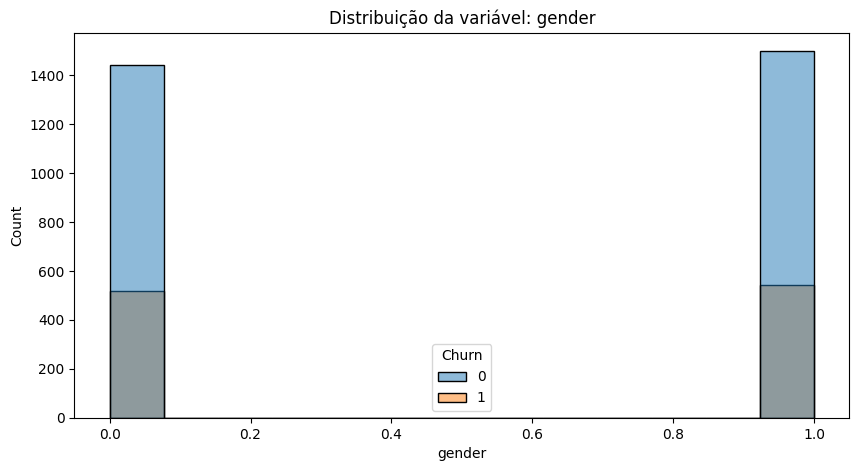

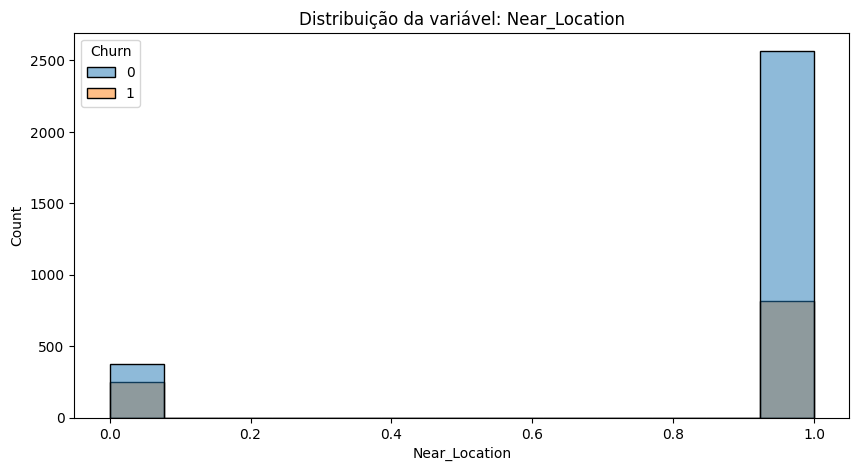

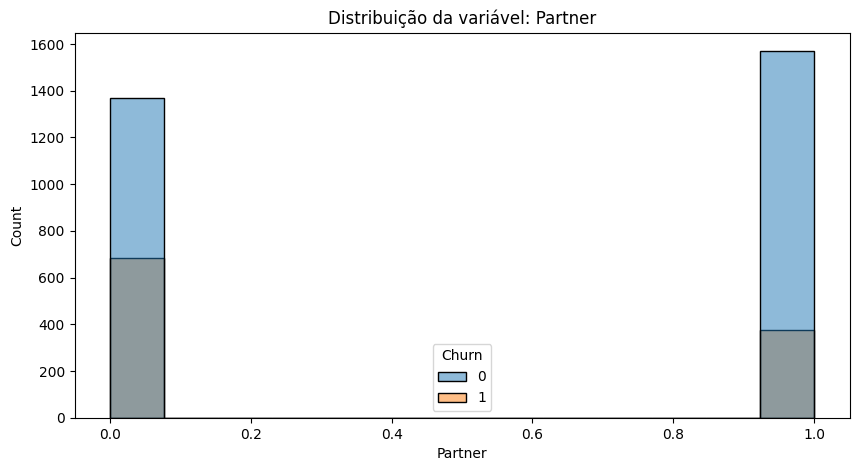

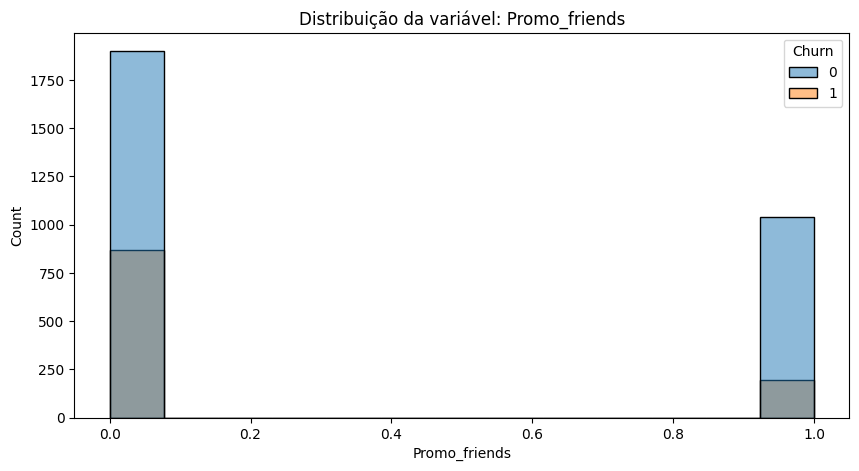

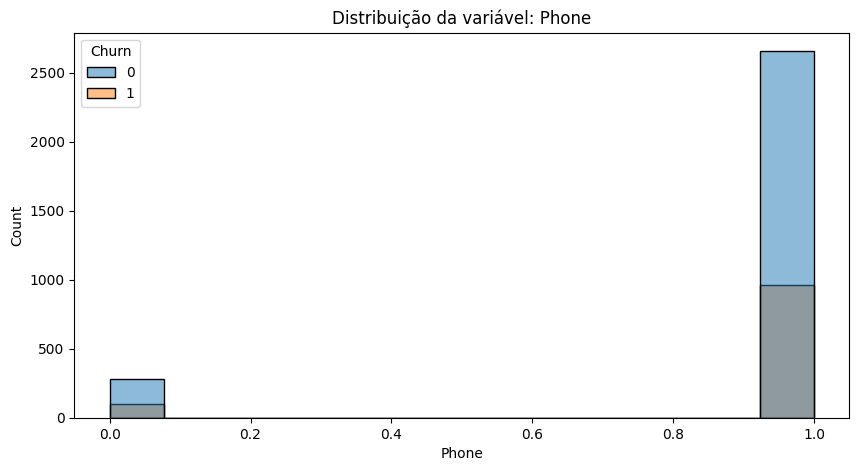

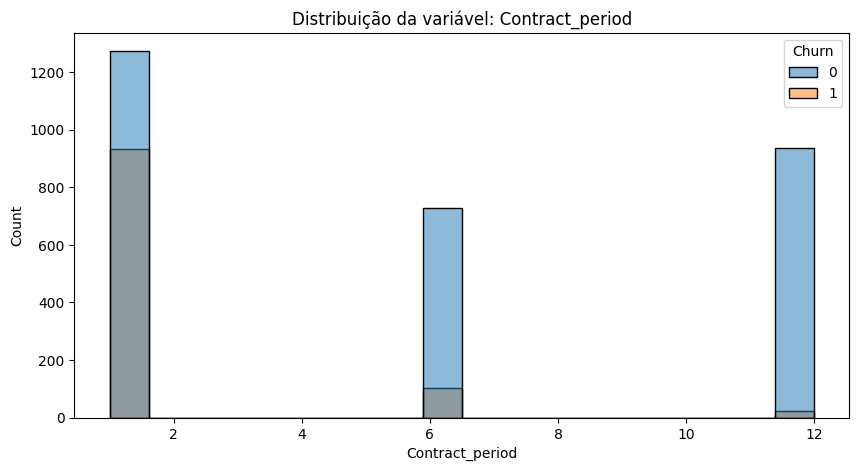

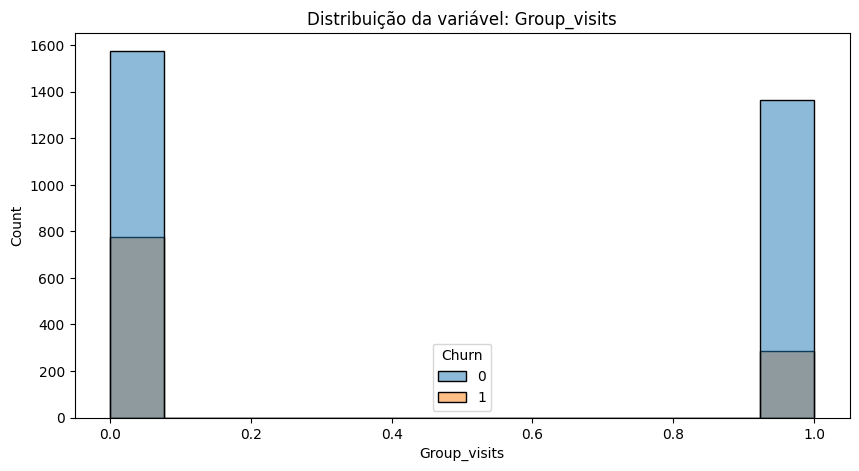

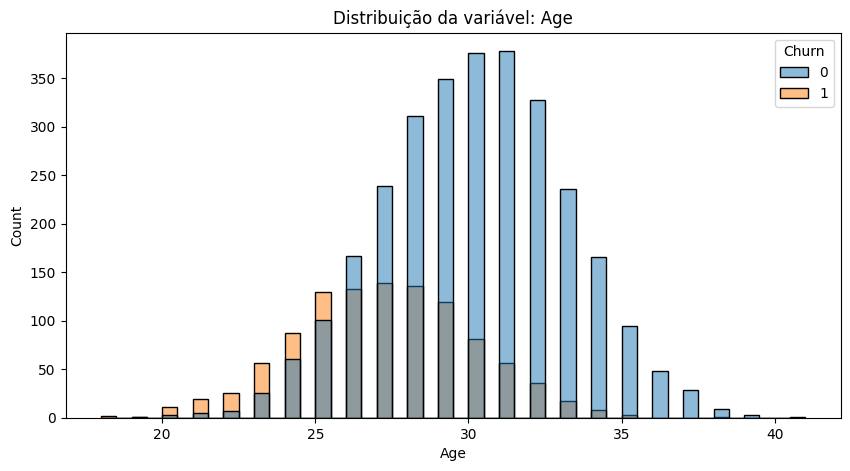

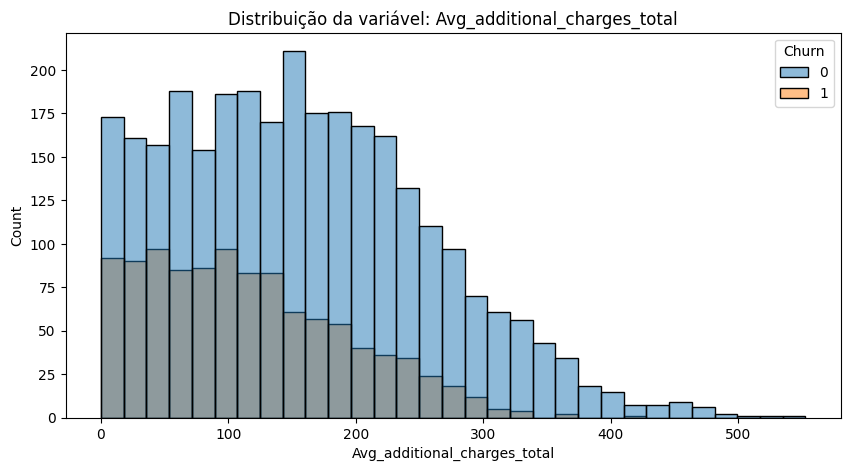

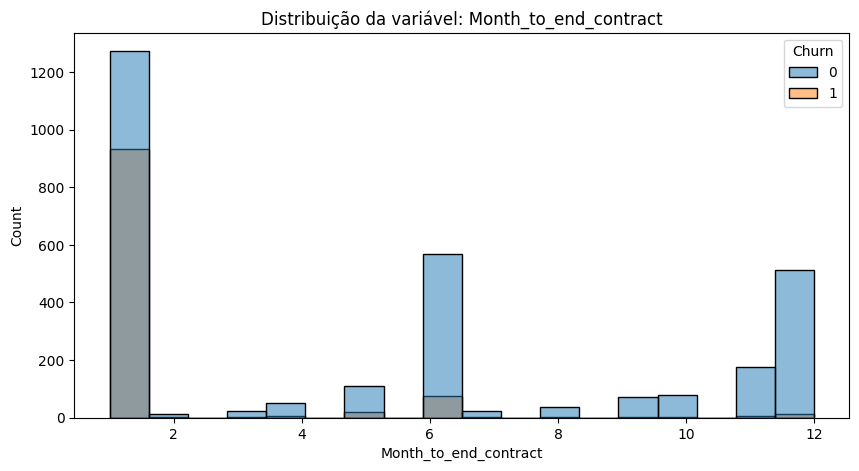

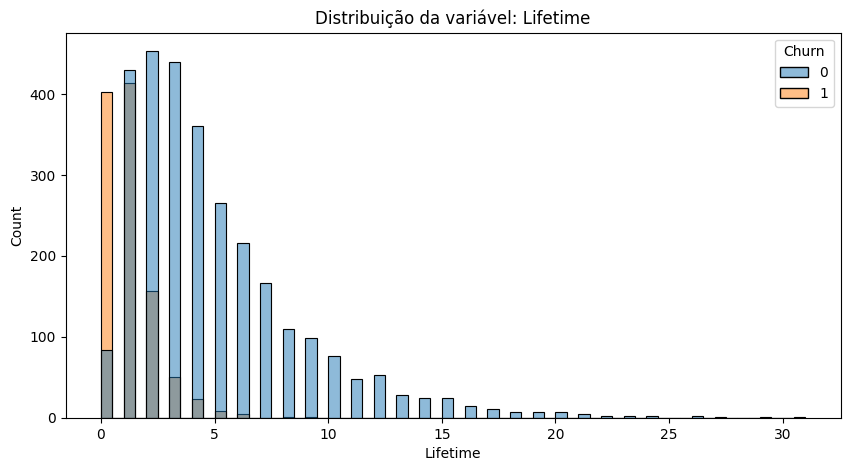

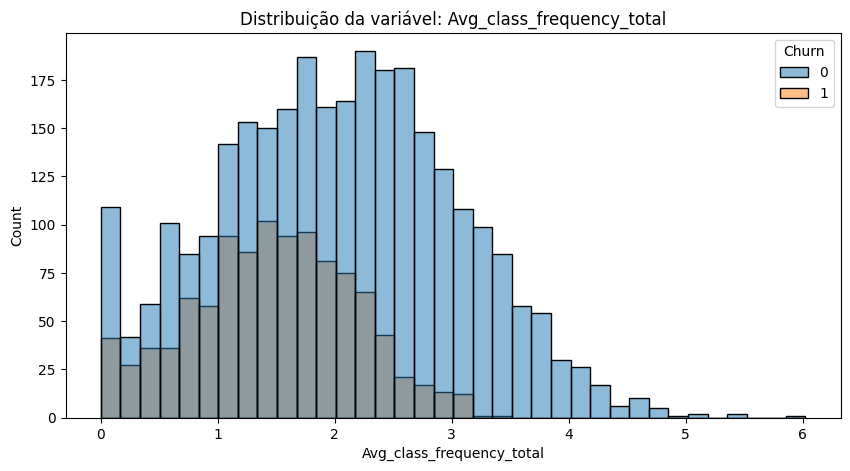

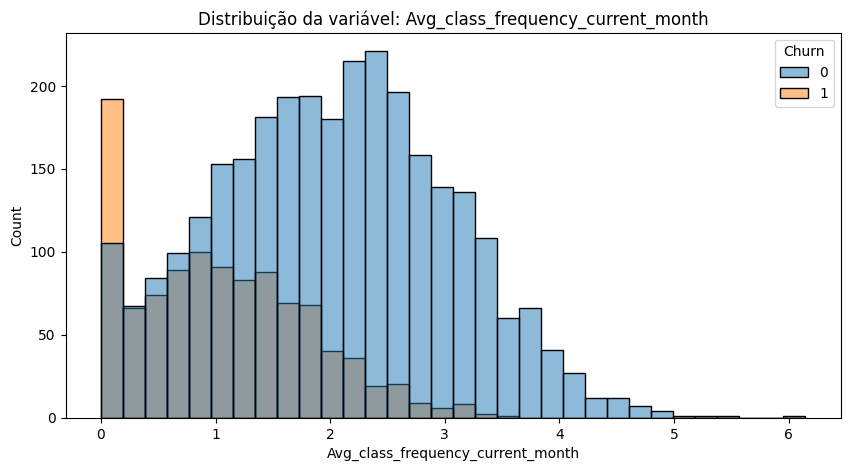

In [5]:
# Histogramas para as características daqueles que saíram
for coluna in gym.columns:
    if coluna == "Churn": 
        continue

    plt.figure(figsize=(10, 5)) # formatando o tamanho das figuras

    # Configurando os gráficos
    sns.histplot(data=gym, x=coluna, hue="Churn")
    # Título para o gráfico
    plt.title(f"Distribuição da variável: {coluna}")
    # Plotando o gráfico
    plt.show()

Os histogramas comprovam visualmente os padrões de cancelamento. No gráfico de idade, o grupo que cancelou o plano concentra-se à esquerda, indicando uma tendência de evasão maior entre os clientes mais jovens. Nas distribuições de "Lifetime" e "Avg_class_frequency_current_month", a concentração de cancelamentos também ocorre à esquerda, nos valores mais baixos. Conclui-se que o perfil de maior risco é o cliente que frequenta a academia há pouco tempo e apresenta uma frequência de treinos menor em comparação aos usuários que permanecem ativos.

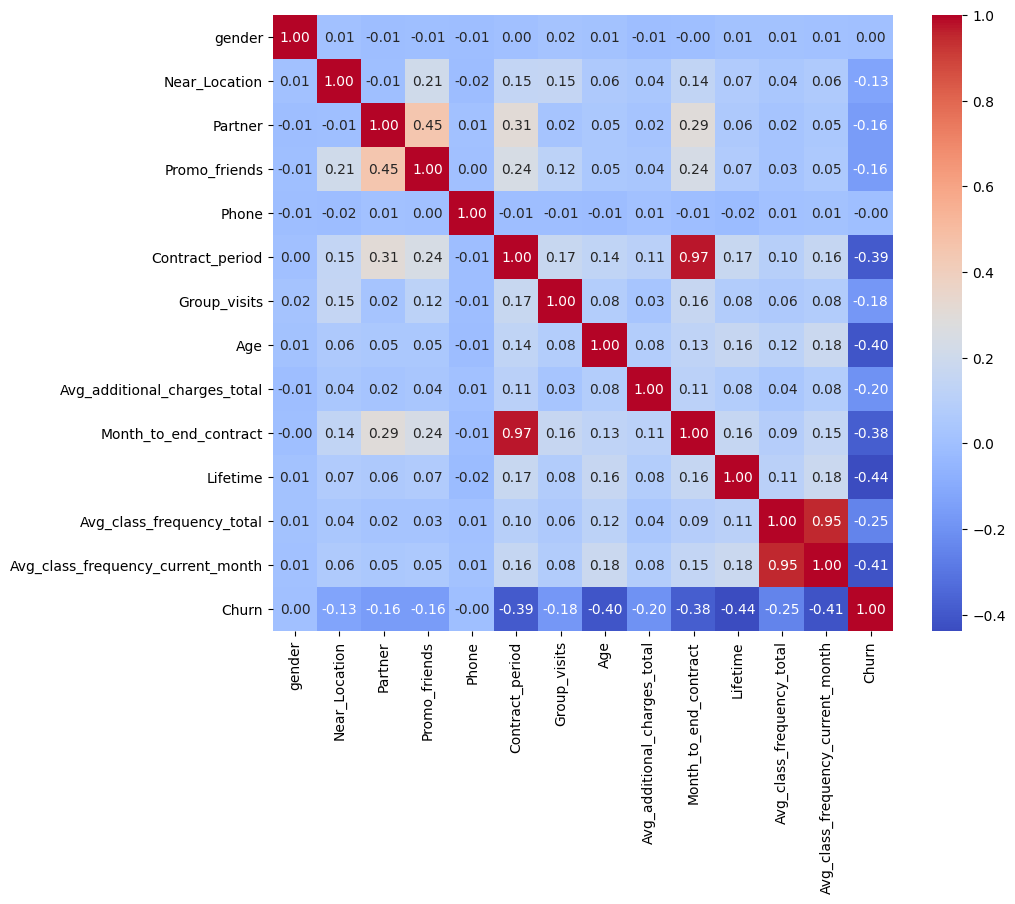

In [6]:

# Criando uma matriz de correlação entre as variáveis e exibindo com um mapa de calor
# Matriz de correlação
cm = gym.corr()

# Ajustamos o tamanho da figura
plt.figure(figsize=(10, 8))

# Criando o mapa de calor
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.show()


Nossa matriz de correlação aponta para dois pares de variáveis com correlação extremamente alta: "Month_to_end_contract" e "Contract_period" (0.97), e "Avg_class_frequency_total" e "Avg_class_frequency_current_month" (0.95). Essa forte correlação mútua é conhecida como multicolinearidade. Manter essas redundâncias impacta negativamente modelos lineares (como a Regressão Logística), pois o algoritmo se confunde ao distribuir os pesos entre variáveis que transmitem exatamente a mesma informação, prejudicando a interpretabilidade e a estabilidade das previsões.

Para garantir o melhor funcionamento do modelo, é adequado remover uma variável de cada dupla. O critério adotado foi manter as características que possuem maior correlação direta com a nossa variável objetivo ("Churn"). Sendo assim, removeremos as colunas "Avg_class_frequency_total" e "Month_to_end_contract".

# 4. Construindo Modelos

In [7]:
# Como definido na etapa anterior, para um melhor desempenho dos nossos modelos,
# iremos remover duas colunas para evitar multicolinearidade entre as variáveis

gym.drop(columns=['Avg_class_frequency_total', 'Month_to_end_contract'], inplace=True)
print(gym.columns)

Index(['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone',
       'Contract_period', 'Group_visits', 'Age',
       'Avg_additional_charges_total', 'Lifetime',
       'Avg_class_frequency_current_month', 'Churn'],
      dtype='object')


In [8]:
# Dividimos os dados em variáveis características e variável objetivo
X = gym.drop(['Churn'], axis=1) # características
y = gym['Churn'] #objetivo

# Dividimos os dados em conjuntos de treino e teste na proporção 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Criamos um objeto StandardScaler e aplicamos nos conjuntos de treino e teste
scaler = StandardScaler()
X_train_st = scaler.fit_transform(X_train) 
X_test_st = scaler.transform(X_test)

In [9]:
# Criamos uma função para receber o modelo, os dados como entrada e exibe
# as métricas de classificação
def make_prediction(m, X_train, y_train, X_test, y_test):
    model = m
    # Treinando o modelo
    model.fit(X_train, y_train)
    # Gerando as previsões
    y_pred = model.predict(X_test)

    # Imprimindo as métricas exigidas
    print("Acurácia: {:.2f} | Precisão: {:.2f} | Sensibilidade (recall): {:.2f}".format(
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred)
    ))

In [10]:
# Criamos uma lista com os modelos exigidos e usamos um laço For para aplicar a função
# aos modelos

models = [LogisticRegression(random_state=0), RandomForestClassifier(random_state=0)]

for i in models:
    # Imprimimos o nome do modelo para melhorar a visualização/identificação
    print(f"\nModelo: {type(i).__name__}")
    make_prediction(i, X_train_st, y_train, X_test_st, y_test)


Modelo: LogisticRegression
Acurácia: 0.90 | Precisão: 0.79 | Sensibilidade (recall): 0.82

Modelo: RandomForestClassifier
Acurácia: 0.90 | Precisão: 0.81 | Sensibilidade (recall): 0.75


Ambos os modelos apresentaram uma acurácia idêntica de 90%, indicando um excelente desempenho geral. Porém, o melhor modelo para a Model Fitness está no equilíbrio entre as métricas de precisão e sensibilidade (recall), avaliadas no contexto do negócio.

A Floresta Aleatória apresentou uma precisão levemente superior (81% contra 79%), mas a Regressão Logística obteve uma vantagem significativa na sensibilidade (82% contra 75%).

Levando em conta a estratégia de retenção, o custo de um Falso Negativo (deixar de identificar um cliente propenso ao cancelamento e perder sua receita) é consideravelmente maior do que o custo de um Falso Positivo (investir esforço de retenção em um cliente leal). Como o objetivo central do projeto é identificar e agir sobre clientes em risco, a métrica principal é a sensibilidade.

Portanto, o modelo de Regressão Logística rendeu os melhores resultados práticos, pois minimiza a perda silenciosa de clientes e garante que a academia tenha a oportunidade de intervir antes do cancelamento da assinatura.

# 5. Agrupamentos de Clientes

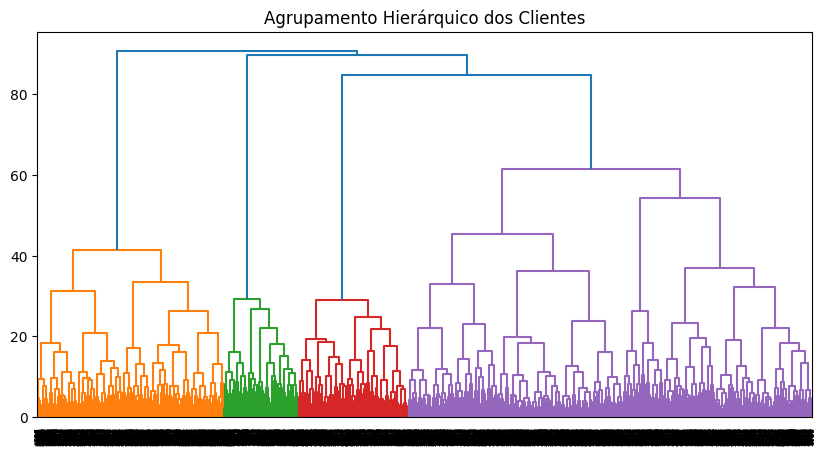

In [11]:
# Isolamos as características
X_cluster = gym.drop(['Churn'], axis=1)

# Padronizamos a base completa
sc = StandardScaler()
X_cluster_st = sc.fit_transform(X_cluster)

# Construímos a matriz de distância
# O método 'ward' minimiza a variância dentro de cada grupo formado
linked = linkage(X_cluster_st, method='ward')

# Plotamos o Dendrograma
plt.figure(figsize=(10, 5))
dendrogram(linked, orientation="top")
plt.title("Agrupamento Hierárquico dos Clientes")
plt.show()

A análise visual do dendrograma sugere a divisão ideal de clientes em 4 agrupamentos. Podemos concluir isso ao observar a maior distância vertical sem cruzamentos, que intercepta 4 ramificações principais. Porém, de acordo com as diretrizes e requisitos estabelecidos para o projeto, a modelagem do algoritmo K-Means será feita com 5 clusters (k=5).

In [12]:
# Definimos nosso modelo k_means com 5 agrupamentos
km = KMeans(n_clusters=5, random_state=0)

# Prevemos os agrupamentos para as observações
labels = km.fit_predict(X_cluster_st)

# Salvamos os rótulos gerados em uma nova coluna do DataFrame
gym['cluster_km'] = labels

# Analisamos os valores médios das características por agrupamentos
cluster_means = gym.groupby("cluster_km").mean()

print(cluster_means)

              gender  Near_Location   Partner  Promo_friends  Phone  \
cluster_km                                                            
0           0.496447       0.995939  0.892386       1.000000    1.0   
1           0.500000       0.000000  0.489247       0.078853    1.0   
2           0.500940       1.000000  0.217105       0.072368    1.0   
3           0.534260       0.996028  0.379345       0.009930    1.0   
4           0.523316       0.862694  0.471503       0.305699    0.0   

            Contract_period  Group_visits        Age  \
cluster_km                                             
0                  6.922843      0.524873  29.606091   
1                  2.994624      0.232975  28.679211   
2                  2.010338      0.277256  27.583647   
3                  6.208540      0.538232  30.699106   
4                  4.777202      0.427461  29.297927   

            Avg_additional_charges_total  Lifetime  \
cluster_km                                           
0

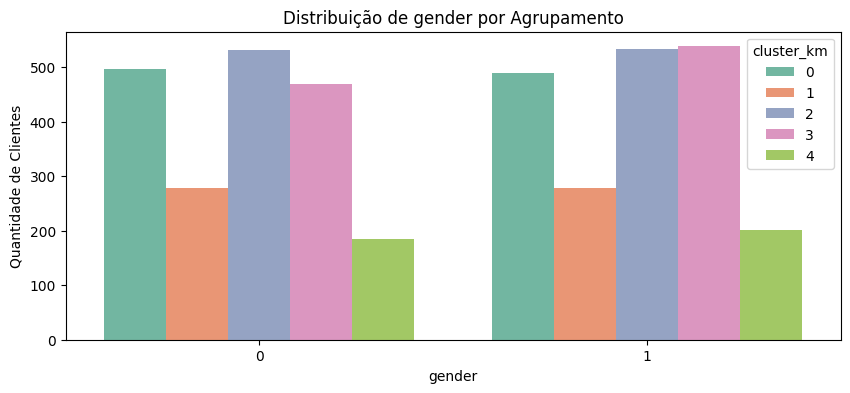

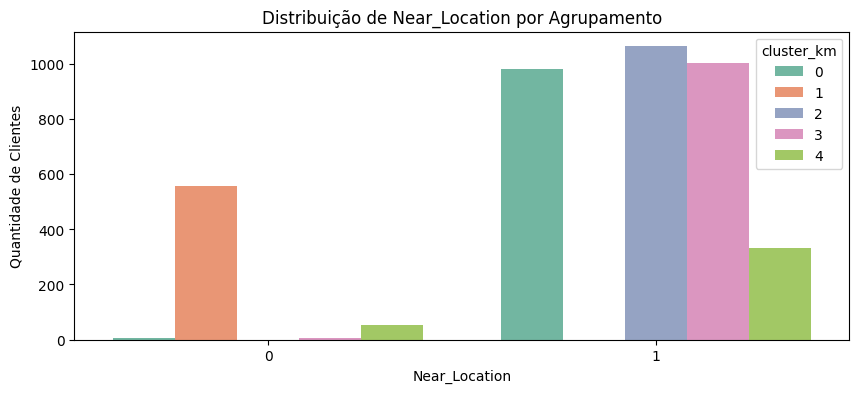

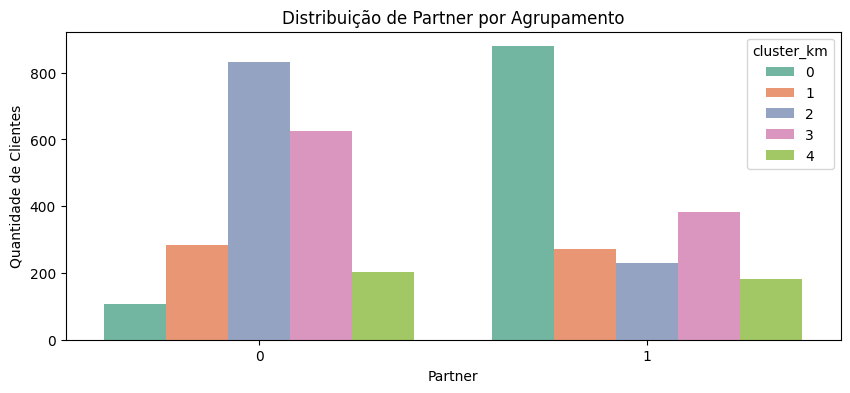

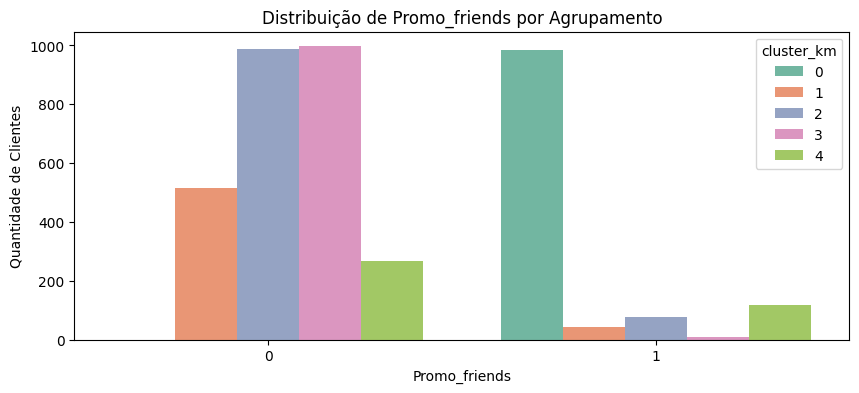

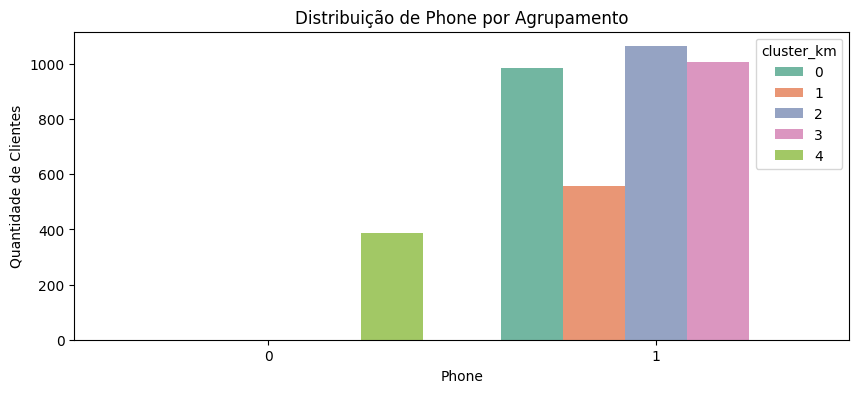

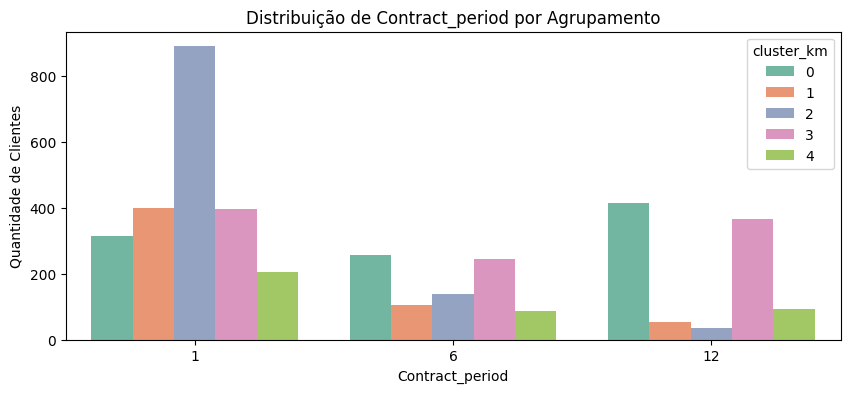

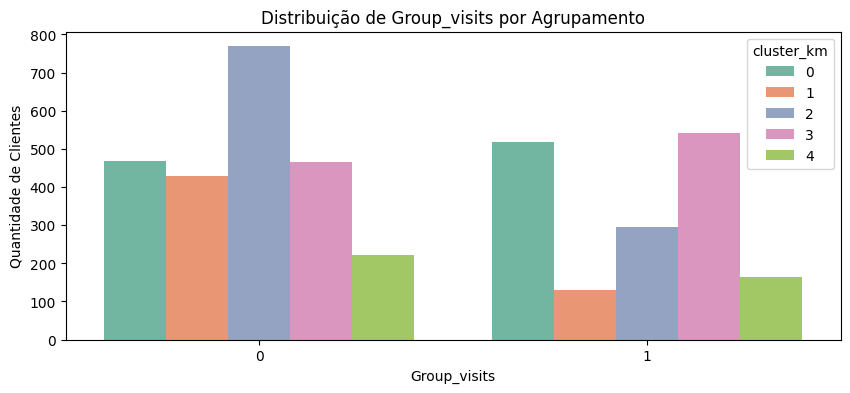

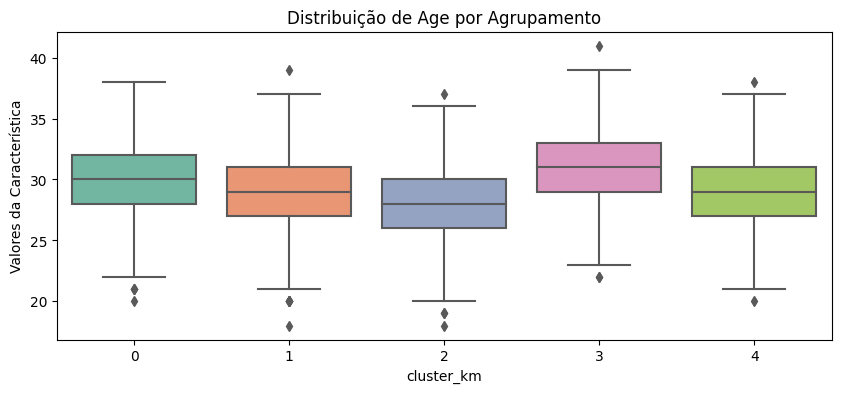

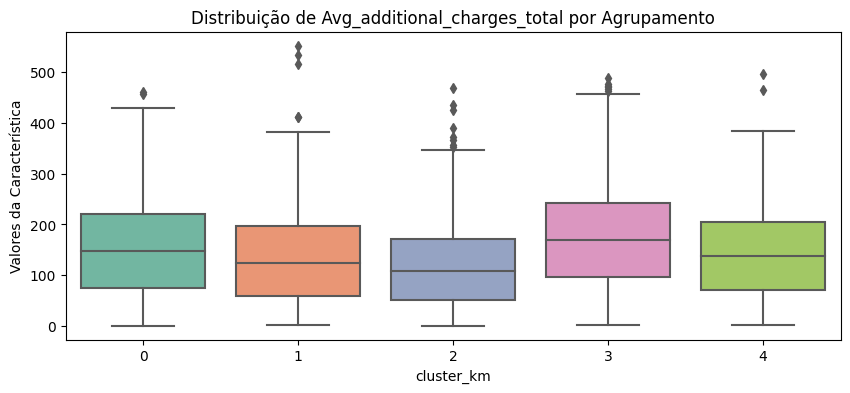

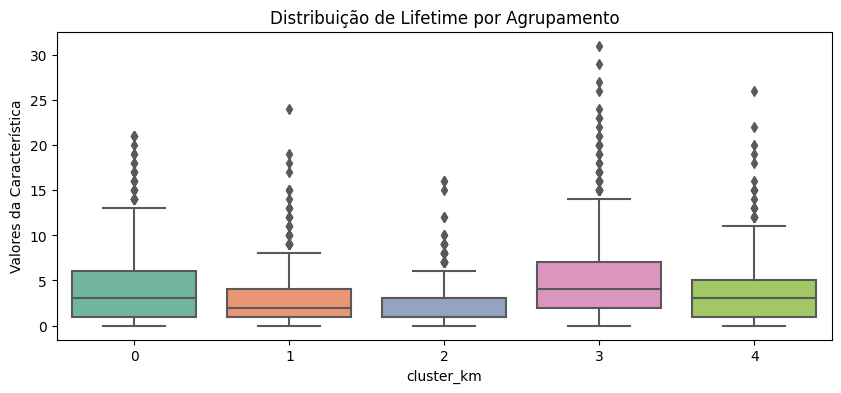

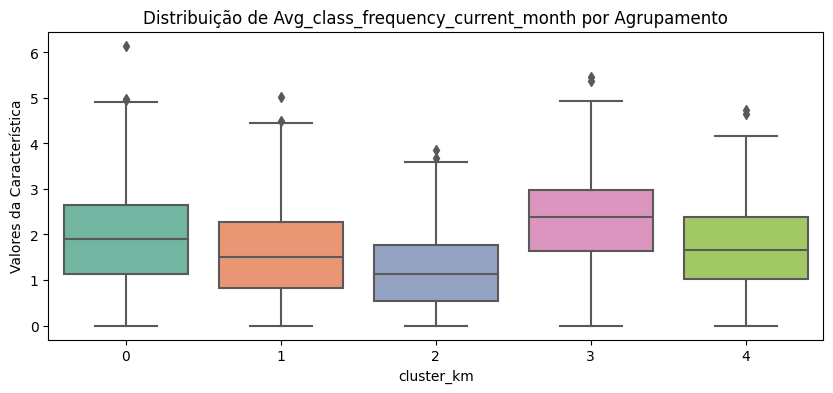

In [18]:
# Para criar distribuições das características, primeiro isolamos as variáveis que queromos plotar
features = gym.drop(columns=['Churn', 'cluster_km']).columns

# Criamos um laço For para gerar um gráfico adequado para cada tipo de característica
for feature in features:
    plt.figure(figsize=(10, 4))

    # Variáveis categóricas ou binárias -> gráfico de barras
    if gym[feature].nunique() <= 5:
        sns.countplot(data=gym, x=feature, hue='cluster_km', palette='Set2')
        plt.title(f"Distribuição de {feature} por Agrupamento")
        plt.ylabel("Quantidade de Clientes")

    # Variáveis contínuas (idade, lifetime, Frequência etc) -> boxplot
    else:
        sns.boxplot(data=gym, x='cluster_km', y=feature, palette='Set2')
        plt.title(f"Distribuição de {feature} por Agrupamento")
        plt.ylabel("Valores da Característica")

    plt.show()

Diversos pontos chamam nossa atenção ao observar os valores médios para as características de cada agrupamento, revelando perfis comportamentais muito distintos.

Começando pelos grupos com as maiores taxas de cancelamento (Grupos 1 e 2). O Grupo 1, com taxa de evasão de 40%, concentra absolutamente todos os usuários que não moram ou trabalham perto da academia, indicando que a distância é um fator decisivo na retenção. A duração média dos contratos e o fator social (sessões em grupos) também mostram números menores em comparação aos grupos fiéis. Um detalhe analítico importante: a duração média de contrato para este grupo (2.99 meses) é praticamente idêntica ao tempo em que eles passaram na academia (Lifetime de 2.97 meses), o que indica que eles apenas cumprem o plano inicial e não renovam.

Já o Grupo 2 representa o cenário mais crítico, com a maior taxa de cancelamento da rede (56%). Neste perfil, a duração média do contrato é de 2 meses, mas o tempo desde a primeira visita (Lifetime) é de apenas 1.92 meses; ou seja, a maioria sequer completa o primeiro contrato firmado. São usuários com baixíssimo engajamento: possuem a menor frequência semanal, são os que menos vivenciam o ecossistema da academia (menor gasto com serviços adicionais), participam de poucas sessões em grupo e são os clientes mais novos. Um dado contraintuitivo é que todos deste grupo moram ou trabalham próximos à academia, provando claramente que apenas a conveniência geográfica não determina a retenção se não houver engajamento.

Em contrapartida, o Grupo 3 representa os usuários com a menor taxa de cancelamento, com uma média de apenas 1,4% — o cenário ideal para o negócio. São os usuários mais velhos na média (faixa dos 30 anos). Esse fator idade possivelmente está relacionado a uma maior estabilidade econômica, pois são os que mais geram receita extra para a academia, consumindo e usufruindo mais dos serviços oferecidos. Além disso, realizam contratos mais longos (média de 6.2 meses) e são os mais engajados em aulas conjuntas, sendo um forte indício de que o fator social exerce grande influência na permanência. Consequentemente, possuem o maior tempo de vida na base (Lifetime de 5.4 meses).

Outro pilar de retenção importante é o Grupo 0 (Churn de 11,9%). Este cluster revelou a força do marketing B2B e do "boca a boca": ele é formado integralmente por pessoas que vieram indicadas por amigos e quase totalmente por funcionários de empresas parceiras. Esse incentivo corporativo/social faz com que eles assinem os contratos mais longos da academia (média de quase 7 meses), garantindo uma receita previsível.

Por fim, do ponto de vista estatístico, é notável observar que a variável 'Gênero' se manteve perfeitamente equilibrada (próxima a 0.50) em todos os cinco agrupamentos. Isso comprova que o sexo do cliente não exerce nenhuma influência no seu nível de engajamento ou na sua probabilidade de cancelar o plano.

# 6. Conclusões

Com base no diagnóstico dos perfis de clientes, a estratégia de retenção da Model Fitness deve evoluir de um modelo passivo para uma abordagem ativa e focada no engajamento comportamental. O primeiro e mais urgente passo é aplicar o princípio da intervenção precoce no Cluster 2, o grupo de maior risco. Como esses clientes tendem a cancelar no primeiro ou segundo mês por falta de engajamento na rotina da academia, a recomendação é utilizar o modelo preditivo para acionar alertas logo na segunda semana de contrato. Para os clientes sinalizados, a equipe de marketing deve disparar comunicações proativas oferecendo uma avaliação física gratuita ou um passe VIP para convidar um amigo, com o objetivo de quebrar a inércia antes do vencimento da primeira fatura.

Em paralelo, é fundamental alavancar os comportamentos dos grupos mais leais. Para o Cluster 0, que demonstrou o peso das parcerias e do fator social na manutenção de contratos longos, a academia deve escalar seu programa de indicação, oferecendo descontos expressivos na mensalidade para usuários que trouxerem amigos que permaneçam ativos. Simultaneamente, a equipe de vendas deve mapear empresas no entorno para fechar novos pacotes corporativos. Já para o Cluster 3, composto pelos veteranos, a estratégia muda de retenção para valorização e upsell. A criação de um programa VIP, que ofereça benefícios como janela de reserva antecipada para aulas coletivas disputadas e um sistema de cashback para consumo em serviços extras da academia, reconhece a lealdade e maximiza a receita já garantida por esse público.

Por fim, o Cluster 1 exige uma estratégia focada em mitigação geográfica. Sabendo que a distância é o principal motor para a taxa de evasão de 40% desse grupo, a Model Fitness pode introduzir planos flexíveis ou híbridos. Ao detectar uma queda abrupta na assiduidade de um cliente que reside ou trabalha longe, a equipe de retenção deve agir rapidamente oferecendo a migração para um pacote de custo reduzido com acessos limitados aos finais de semana, ou integrado a um aplicativo oficial de treinos em casa. Essa adaptação preserva a base de clientes e garante a manutenção da receita, evitando a perda total do usuário pelo simples desgaste do deslocamento diário.